# InsurIQ — Full EDA, Anomaly Detection & Feature Engineering
**Dataset:** fraud_oracle.csv — 15,420 insurance claims  
**Goal:** Identify all anomalies, clean data, engineer features, export cleaned CSV

In [1]:
import sys
import os

print("Python:", sys.executable)
print("File exists:", os.path.exists(r'D:\FDE\InsurIQ\Data\fraud_oracle.csv'))

Python: d:\FDE\InsurIQ\backend\venv310\Scripts\python.exe
File exists: True


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Load data — update path as needed
df = pd.read_csv(r'D:\FDE\InsurIQ\Data\fraud_oracle.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (15420, 33)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision


## 1. Basic Info

In [3]:
print('=== DATA TYPES ===')
print(df.dtypes)
print()
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values')
print()
print('=== FRAUD DISTRIBUTION ===')
fraud_counts = df['FraudFound_P'].value_counts()
print(fraud_counts)
print(f'Fraud rate: {fraud_counts[1]/len(df)*100:.2f}%')

=== DATA TYPES ===
Month                   object
WeekOfMonth              int64
DayOfWeek               object
Make                    object
AccidentArea            object
DayOfWeekClaimed        object
MonthClaimed            object
WeekOfMonthClaimed       int64
Sex                     object
MaritalStatus           object
Age                      int64
Fault                   object
PolicyType              object
VehicleCategory         object
VehiclePrice            object
FraudFound_P             int64
PolicyNumber             int64
RepNumber                int64
Deductible               int64
DriverRating             int64
Days_Policy_Accident    object
Days_Policy_Claim       object
PastNumberOfClaims      object
AgeOfVehicle            object
AgeOfPolicyHolder       object
PoliceReportFiled       object
WitnessPresent          object
AgentType               object
NumberOfSuppliments     object
AddressChange_Claim     object
NumberOfCars            object
Year                

## 2. Class Imbalance

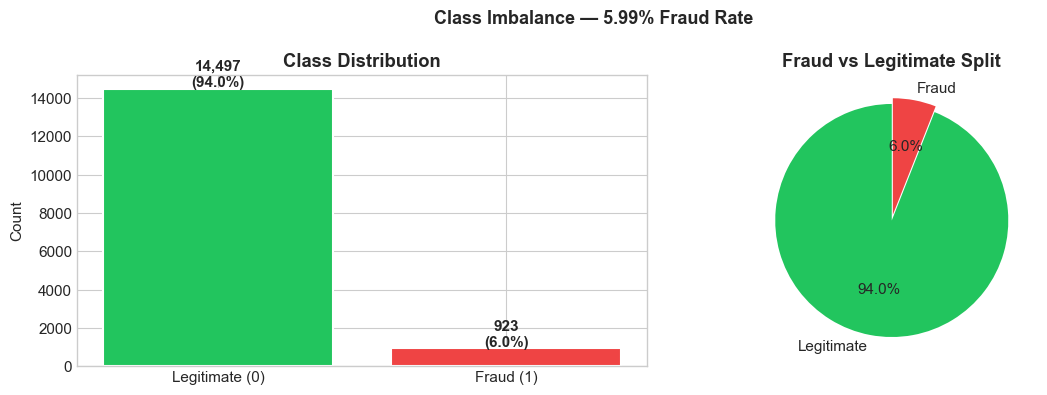

Imbalance ratio 1:15.7 (fraud:legitimate) — significant class imbalance


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['FraudFound_P'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], counts.values,
            color=['#22C55E', '#EF4444'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Legitimate', 'Fraud'],
            colors=['#22C55E', '#EF4444'], autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Fraud vs Legitimate Split', fontweight='bold')

plt.suptitle('Class Imbalance — 5.99% Fraud Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('01_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Imbalance ratio 1:15.7 (fraud:legitimate) — significant class imbalance')

## 3. Anomaly Detection & Documentation

In [5]:
anomalies = []

# Anomaly 1: Age = 0
age_zero = df[df['Age'] == 0]
anomalies.append({
    'id': 'A1', 'column': 'Age',
    'issue': 'Age = 0 (impossible for an adult driver)',
    'count': len(age_zero),
    'fix': 'Impute from AgeOfPolicyHolder band midpoint'
})
print(f'A1 — Age=0: {len(age_zero)} rows')
print(df[df['Age']==0]['AgeOfPolicyHolder'].value_counts())
print()

A1 — Age=0: 320 rows
AgeOfPolicyHolder
16 to 17    320
Name: count, dtype: int64



In [6]:
# Anomaly 2: DayOfWeekClaimed = '0' and MonthClaimed = '0'
dow_zero = df[df['DayOfWeekClaimed'] == '0']
anomalies.append({
    'id': 'A2', 'column': 'DayOfWeekClaimed / MonthClaimed',
    'issue': "1 row where DayOfWeekClaimed='0' and MonthClaimed='0'",
    'count': len(dow_zero),
    'fix': 'Impute from DayOfWeek and Month (accident date = claim date assumption)'
})
print(f'A2 — DayOfWeekClaimed=0: {len(dow_zero)} row')
print(dow_zero[['PolicyNumber','DayOfWeek','DayOfWeekClaimed','Month','MonthClaimed','Age']].to_string())
print()

A2 — DayOfWeekClaimed=0: 1 row
      PolicyNumber DayOfWeek DayOfWeekClaimed Month MonthClaimed  Age
1516          1517    Monday                0   Jul            0    0



In [7]:
# Anomaly 3: PolicyType vs VehicleCategory mismatch — CRITICAL
df['PolicyType_prefix'] = df['PolicyType'].str.split(' - ').str[0]
mismatch = df[df['PolicyType_prefix'] != df['VehicleCategory']]
anomalies.append({
    'id': 'A3', 'column': 'PolicyType / VehicleCategory',
    'issue': f'PolicyType prefix does not match VehicleCategory in {len(mismatch)} rows',
    'count': len(mismatch),
    'fix': 'VehicleCategory is correct. Derive PolicyType from VehicleCategory + BasePolicy'
})
print(f'A3 — PolicyType vs VehicleCategory mismatch: {len(mismatch)} rows ({len(mismatch)/len(df)*100:.1f}%)')
print('Example mismatches:')
print(mismatch[['PolicyType','VehicleCategory','BasePolicy']].head(5))
print()
print('Cross-tab (correct alignment):')
print(pd.crosstab(df['VehicleCategory'], df['BasePolicy']))
print()

A3 — PolicyType vs VehicleCategory mismatch: 4987 rows (32.3%)
Example mismatches:
           PolicyType VehicleCategory BasePolicy
3   Sedan - Liability           Sport  Liability
11  Sedan - Liability           Sport  Liability
12  Sedan - Liability           Sport  Liability
14  Sedan - Liability           Sport  Liability
15  Sedan - Liability           Sport  Liability

Cross-tab (correct alignment):
BasePolicy       All Perils  Collision  Liability
VehicleCategory                                  
Sedan                  4087       5584          0
Sport                    22        348       4988
Utility                 340         30         21



In [8]:
# Anomaly 4: Age vs AgeOfPolicyHolder band mismatch
age_map = {
    '16 to 17': (16,17), '18 to 20': (18,20), '21 to 25': (21,25),
    '26 to 30': (26,30), '31 to 35': (31,35), '36 to 40': (36,40),
    '41 to 50': (41,50), '51 to 65': (51,65), 'over 65': (66,120)
}
def age_in_band(row):
    if row['Age'] == 0: return True  # Age=0 handled separately
    band = age_map.get(row['AgeOfPolicyHolder'])
    if not band: return True
    return band[0] <= row['Age'] <= band[1]

age_mismatch = df[~df.apply(age_in_band, axis=1)]
anomalies.append({
    'id': 'A4', 'column': 'Age / AgeOfPolicyHolder',
    'issue': f'Age value falls outside AgeOfPolicyHolder band in {len(age_mismatch)} rows',
    'count': len(age_mismatch),
    'fix': 'Trust AgeOfPolicyHolder (ordinal band) over Age (continuous). Impute Age from band midpoint.'
})
print(f'A4 — Age vs AgeOfPolicyHolder mismatch: {len(age_mismatch)} rows ({len(age_mismatch)/len(df)*100:.1f}%)')
print('Sample:')
print(age_mismatch[['Age','AgeOfPolicyHolder']].head(10))
# Pattern: Age is consistently off by about 5 years
age_mismatch_excl_zero = age_mismatch[age_mismatch['Age'] > 0].copy()
age_mismatch_excl_zero['band_min'] = age_mismatch_excl_zero['AgeOfPolicyHolder'].map(lambda x: age_map.get(x,(0,0))[0])
age_mismatch_excl_zero['diff'] = age_mismatch_excl_zero['Age'] - age_mismatch_excl_zero['band_min']
print(f'\nAge - band_min difference stats:')
print(age_mismatch_excl_zero['diff'].describe())
print()

A4 — Age vs AgeOfPolicyHolder mismatch: 6922 rows (44.9%)
Sample:
    Age AgeOfPolicyHolder
0    21          26 to 30
4    27          31 to 35
5    20          21 to 25
8    30          31 to 35
9    42          36 to 40
11   52          41 to 50
12   28          31 to 35
16   41          36 to 40
17   28          31 to 35
19   30          31 to 35

Age - band_min difference stats:
count    6922.000000
mean        2.934845
std         6.381341
min        -5.000000
25%        -3.000000
50%        -1.000000
75%         9.000000
max        14.000000
Name: diff, dtype: float64



In [9]:
# Anomaly 5: Deductible=300 — only 8 rows
ded_300 = df[df['Deductible']==300]
anomalies.append({
    'id': 'A5', 'column': 'Deductible',
    'issue': f'Deductible=300 appears only {len(ded_300)} times (0.05%). Likely data entry error.',
    'count': len(ded_300),
    'fix': 'Flag as potential outlier. Keep but note in analysis.'
})
print(f'A5 — Deductible=300: {len(ded_300)} rows')
print(df['Deductible'].value_counts())
print()

A5 — Deductible=300: 8 rows
Deductible
400    14838
700      311
500      263
300        8
Name: count, dtype: int64



In [10]:
# Anomaly 6: Days_Policy_Accident = 'none' — ambiguous
days_none = df[df['Days_Policy_Accident']=='none']
anomalies.append({
    'id': 'A6', 'column': 'Days_Policy_Accident',
    'issue': f"'none' in Days_Policy_Accident ({len(days_none)} rows) — ambiguous meaning",
    'count': len(days_none),
    'fix': "'none' likely means policy was brand new / same day. Treat as '1 to 7' (new policy risk)"
})
print(f'A6 — Days_Policy_Accident=none: {len(days_none)} rows')
print('Fraud rate for none:', days_none['FraudFound_P'].mean().round(3))
print('Fraud rate overall:', df['FraudFound_P'].mean().round(3))
print(df['Days_Policy_Accident'].value_counts())
print()

A6 — Days_Policy_Accident=none: 55 rows
Fraud rate for none: 0.164
Fraud rate overall: 0.06
Days_Policy_Accident
more than 30    15247
none               55
8 to 15            55
15 to 30           49
1 to 7             14
Name: count, dtype: int64



In [11]:
# Anomaly 7: Column name typo
anomalies.append({
    'id': 'A7', 'column': 'NumberOfSuppliments',
    'issue': 'Column name misspelled — should be NumberOfSupplements',
    'count': 0,
    'fix': 'Rename column to NumberOfSupplements'
})
print('A7 — Typo: NumberOfSuppliments → NumberOfSupplements')
print()

# Anomaly 8: DriverRating — unclear direction
anomalies.append({
    'id': 'A8', 'column': 'DriverRating',
    'issue': 'Unclear if 1=best or 1=worst. Fraud rates are similar across all values.',
    'count': 0,
    'fix': 'Treat as categorical. Note: fraud rate barely varies (5.6% to 6.2%)'
})
print('A8 — DriverRating fraud rates:')
print(df.groupby('DriverRating')['FraudFound_P'].agg(['mean','count']).round(3))
print()

# Summary
print('=== ANOMALY SUMMARY ===')
anom_df = pd.DataFrame(anomalies)
print(anom_df[['id','column','count','fix']].to_string())

A7 — Typo: NumberOfSuppliments → NumberOfSupplements

A8 — DriverRating fraud rates:
               mean  count
DriverRating              
1             0.059   3944
2             0.056   3801
3             0.062   3884
4             0.062   3791

=== ANOMALY SUMMARY ===
   id                           column  count                                                                                           fix
0  A1                              Age    320                                                   Impute from AgeOfPolicyHolder band midpoint
1  A2  DayOfWeekClaimed / MonthClaimed      1                       Impute from DayOfWeek and Month (accident date = claim date assumption)
2  A3     PolicyType / VehicleCategory   4987               VehicleCategory is correct. Derive PolicyType from VehicleCategory + BasePolicy
3  A4          Age / AgeOfPolicyHolder   6922  Trust AgeOfPolicyHolder (ordinal band) over Age (continuous). Impute Age from band midpoint.
4  A5                       

## 4. Univariate Analysis

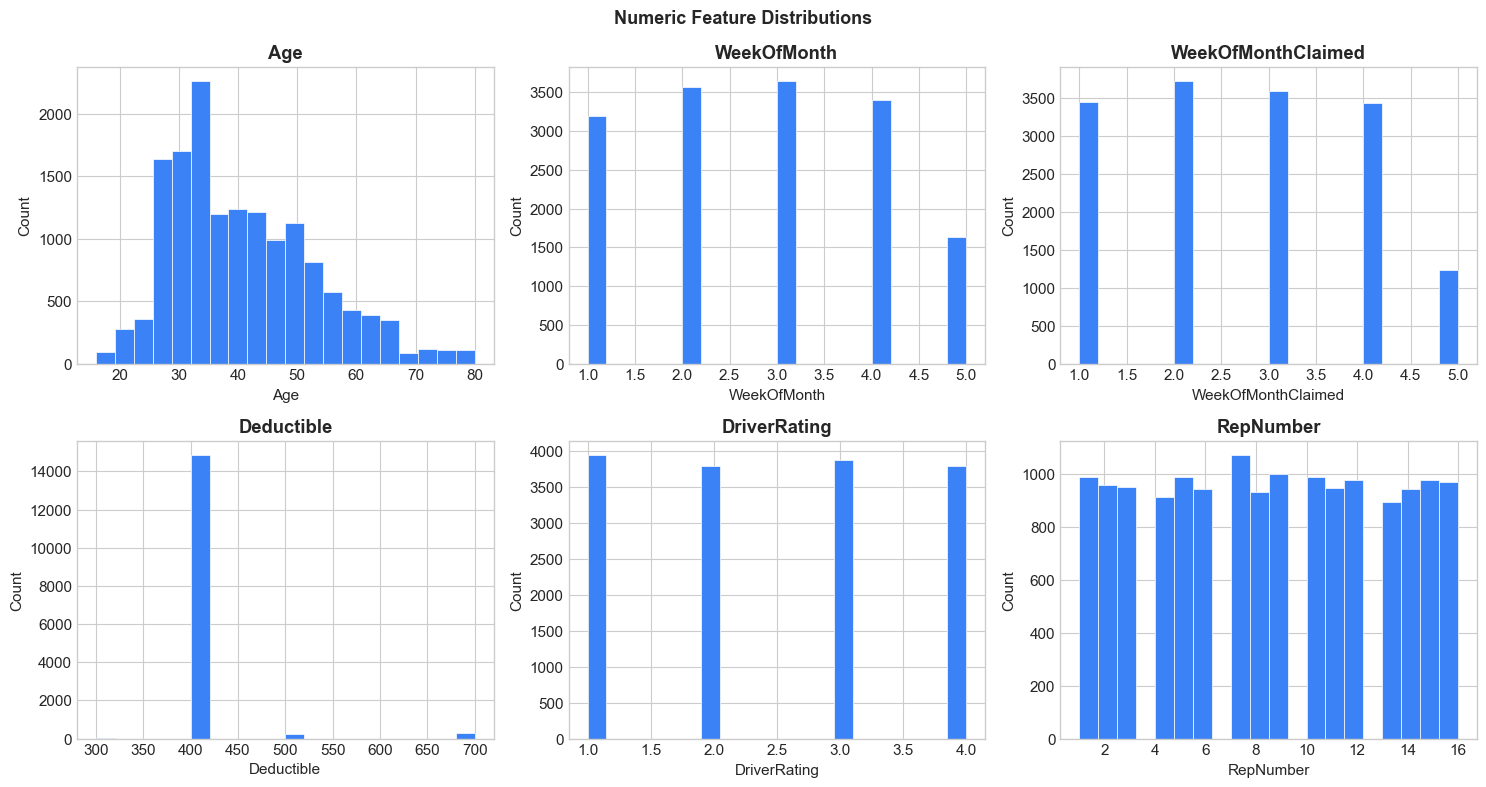

In [12]:
# Numeric columns
numeric_cols = ['Age','WeekOfMonth','WeekOfMonthClaimed','Deductible','DriverRating','RepNumber']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    data = df[col] if col != 'Age' else df[df['Age']>0][col]
    axes[i].hist(data, bins=20, color='#3B82F6', edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
plt.suptitle('Numeric Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('02_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

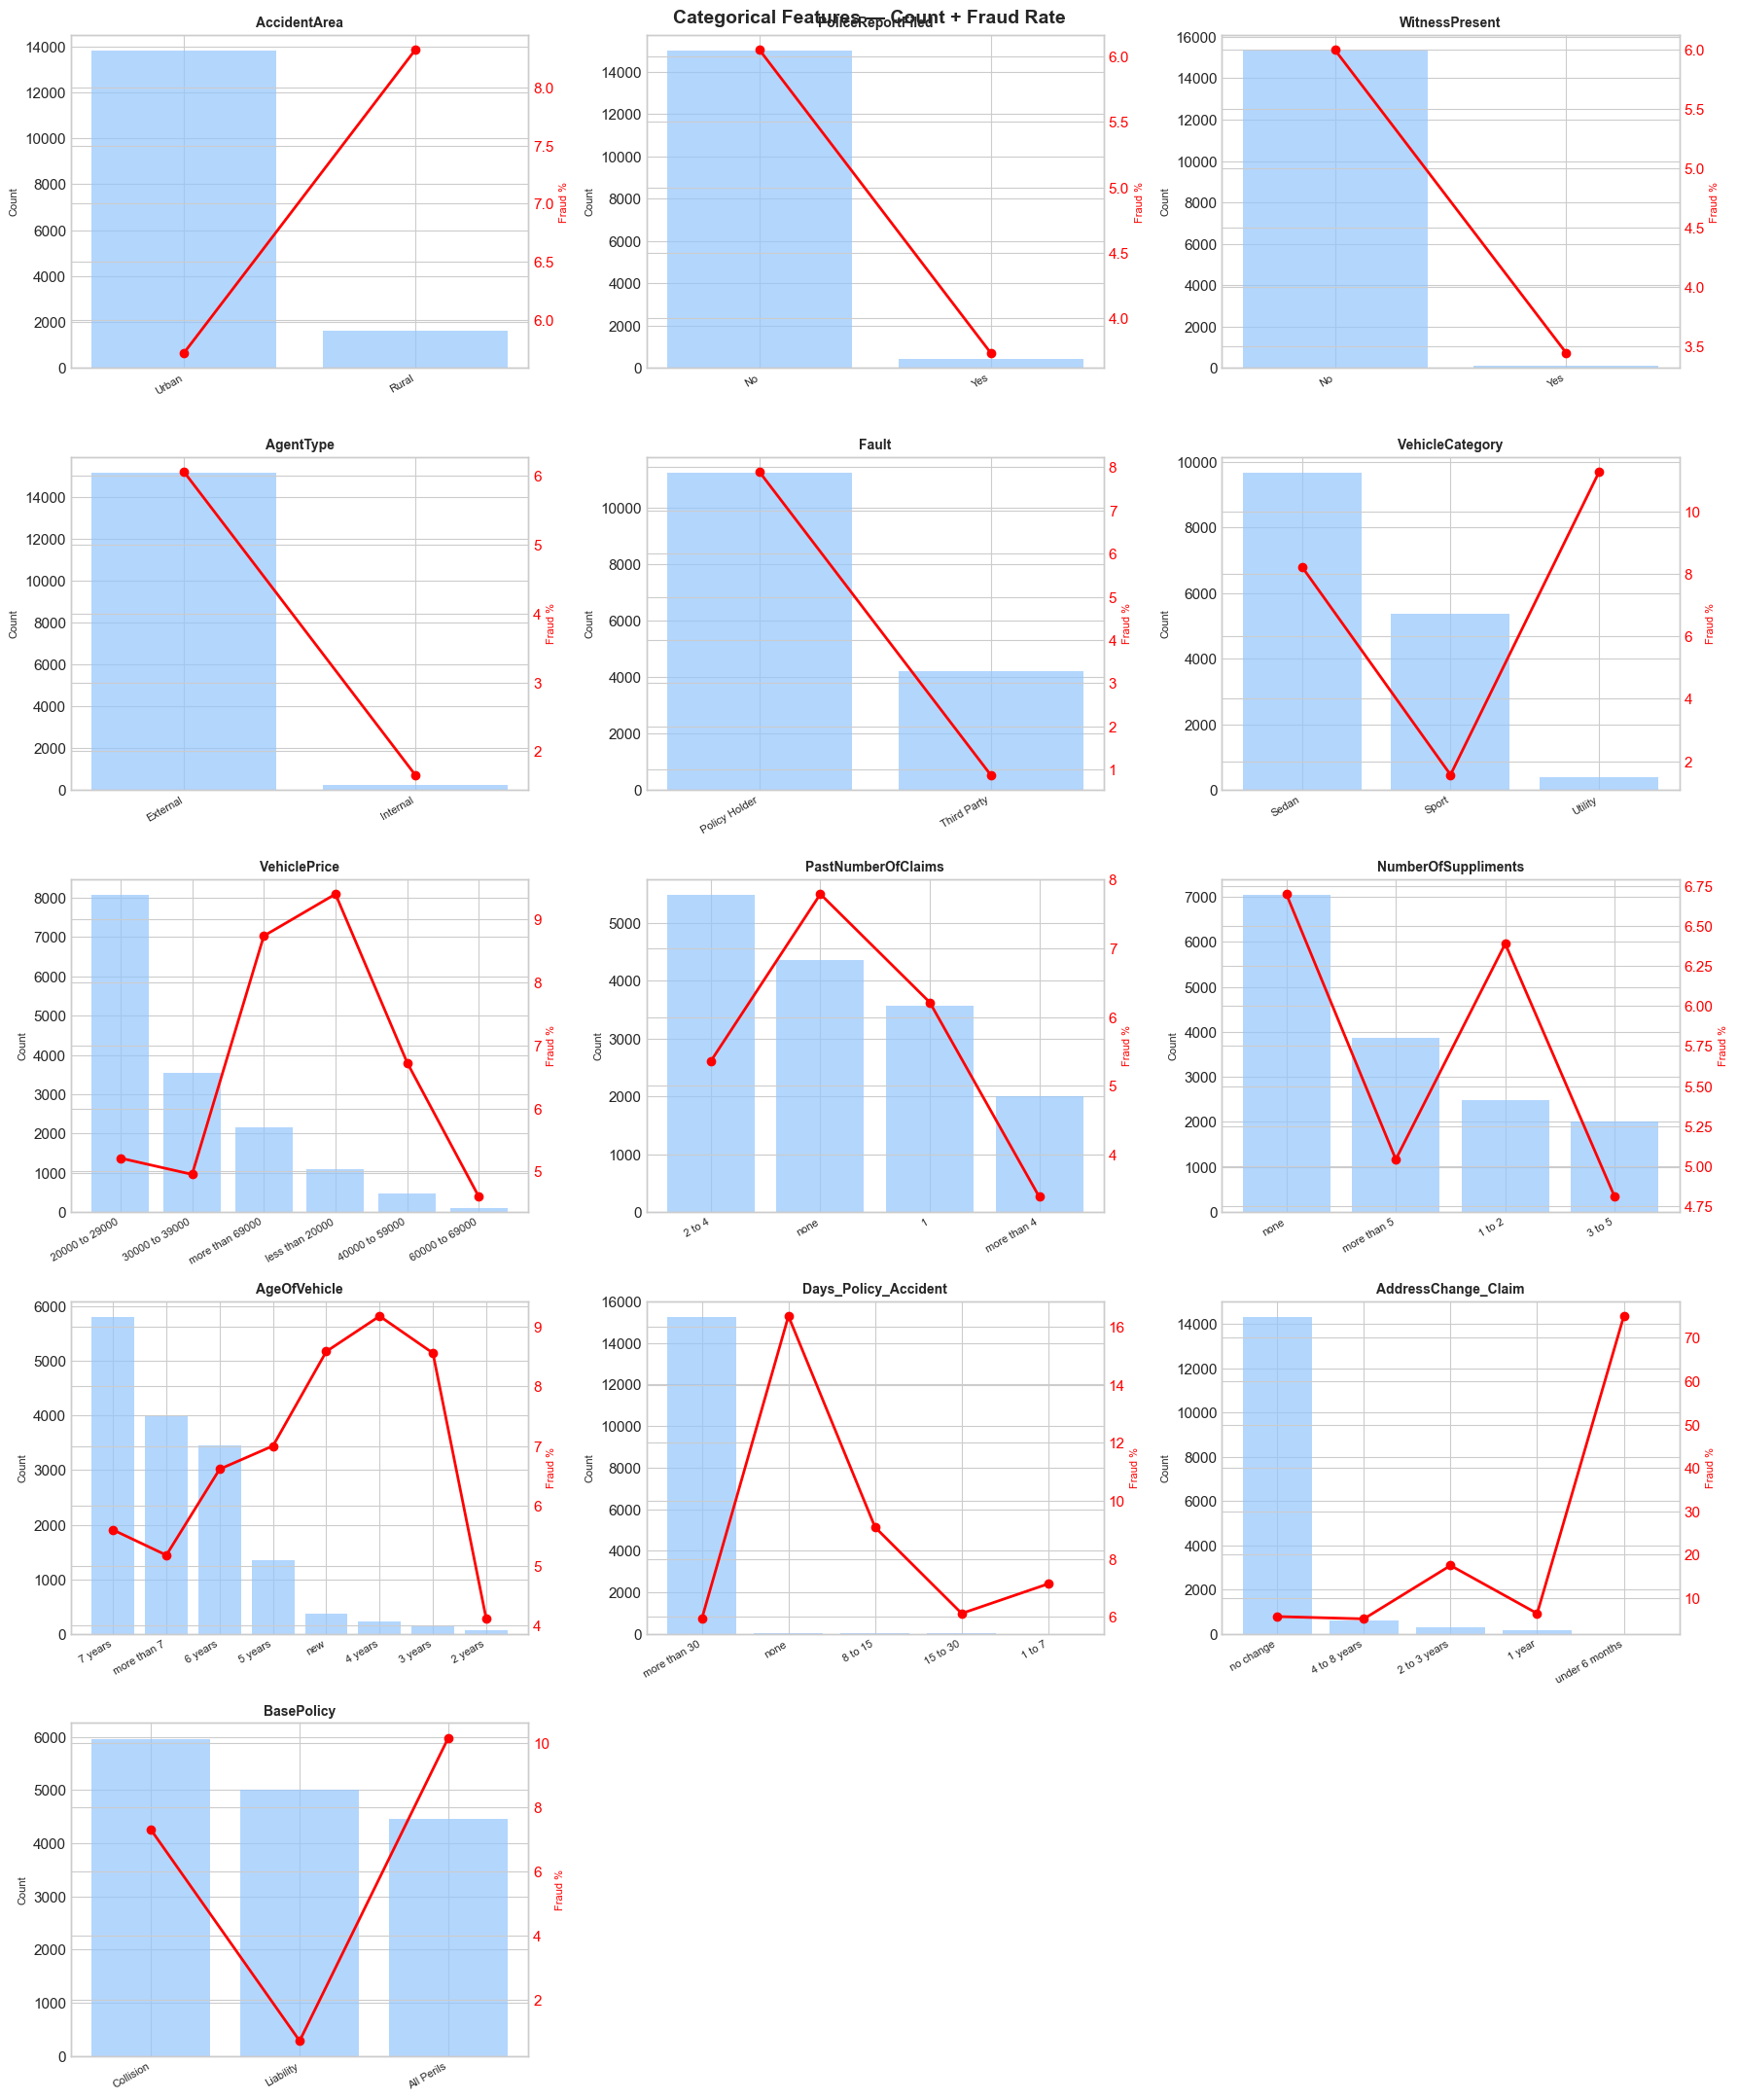

In [13]:
# Categorical columns — fraud rate overlay
cat_cols = ['AccidentArea','PoliceReportFiled','WitnessPresent','AgentType','Fault',
            'VehicleCategory','VehiclePrice','PastNumberOfClaims','NumberOfSuppliments',
            'AgeOfVehicle','Days_Policy_Accident','AddressChange_Claim','BasePolicy']

fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax1 = axes[i]
    ax2 = ax1.twinx()
    
    counts = df[col].value_counts()
    fraud_rate = df.groupby(col)['FraudFound_P'].mean().reindex(counts.index)
    
    x = range(len(counts))
    bars = ax1.bar(x, counts.values, color='#93C5FD', alpha=0.7, label='Count')
    ax2.plot(x, fraud_rate.values * 100, 'ro-', linewidth=2, markersize=6, label='Fraud %')
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(counts.index, rotation=30, ha='right', fontsize=8)
    ax1.set_title(col, fontweight='bold', fontsize=10)
    ax1.set_ylabel('Count', fontsize=8)
    ax2.set_ylabel('Fraud %', color='red', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='red')

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features — Count + Fraud Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Bivariate Analysis — Each Feature vs Fraud

In [14]:
# Fraud rate by each categorical feature
print('=== FRAUD RATE BY FEATURE ===')
results = []
for col in cat_cols:
    group = df.groupby(col)['FraudFound_P'].agg(['mean','count']).reset_index()
    group.columns = [col, 'fraud_rate', 'count']
    group['fraud_rate_pct'] = (group['fraud_rate']*100).round(2)
    max_rate = group['fraud_rate_pct'].max()
    min_rate = group['fraud_rate_pct'].min()
    print(f'\n{col} (range: {min_rate:.1f}% — {max_rate:.1f}%)')
    print(group[[col,'fraud_rate_pct','count']].sort_values('fraud_rate_pct', ascending=False).to_string(index=False))
    results.append({'feature': col, 'max_fraud_rate': max_rate, 'min_fraud_rate': min_rate, 'spread': max_rate-min_rate})

results_df = pd.DataFrame(results).sort_values('spread', ascending=False)
print('\n=== FEATURES RANKED BY FRAUD RATE SPREAD ===')
print(results_df.to_string(index=False))

=== FRAUD RATE BY FEATURE ===

AccidentArea (range: 5.7% — 8.3%)
AccidentArea  fraud_rate_pct  count
       Rural            8.32   1598
       Urban            5.72  13822

PoliceReportFiled (range: 3.7% — 6.0%)
PoliceReportFiled  fraud_rate_pct  count
               No            6.05  14992
              Yes            3.74    428

WitnessPresent (range: 3.5% — 6.0%)
WitnessPresent  fraud_rate_pct  count
            No            6.00  15333
           Yes            3.45     87

AgentType (range: 1.7% — 6.0%)
AgentType  fraud_rate_pct  count
 External            6.05  15179
 Internal            1.66    241

Fault (range: 0.9% — 7.9%)
        Fault  fraud_rate_pct  count
Policy Holder            7.89  11230
  Third Party            0.88   4190

VehicleCategory (range: 1.6% — 11.2%)
VehicleCategory  fraud_rate_pct  count
        Utility           11.25    391
          Sedan            8.22   9671
          Sport            1.57   5358

VehiclePrice (range: 4.6% — 9.4%)
   VehiclePri

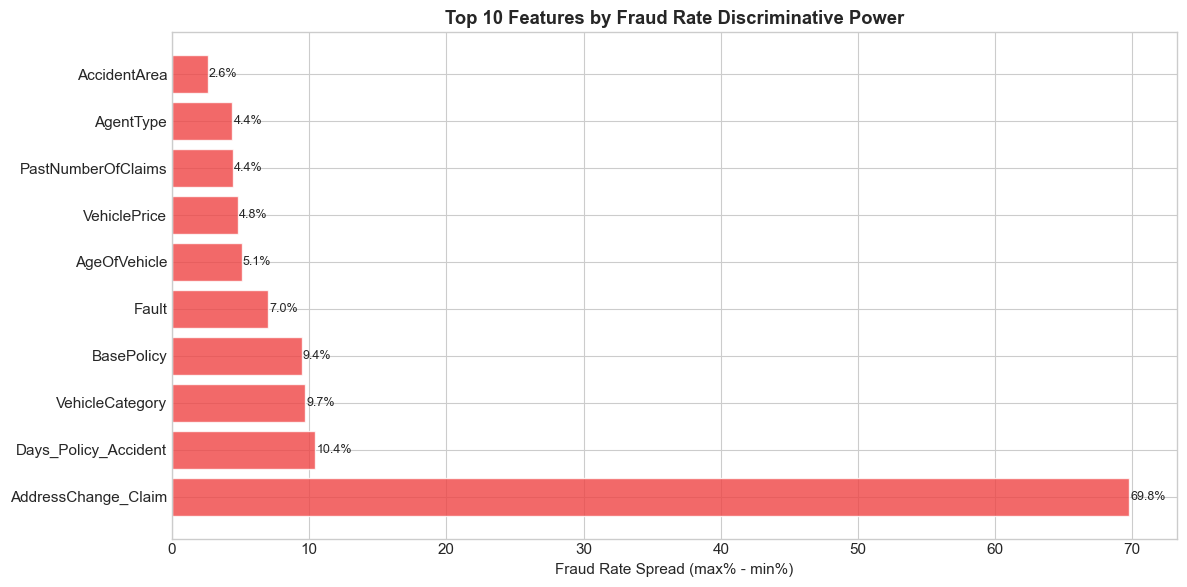

In [15]:
# Top fraud rate spread visualization
fig, ax = plt.subplots(figsize=(12, 6))
top_features = results_df.head(10)
bars = ax.barh(top_features['feature'], top_features['spread'],
               color='#EF4444', alpha=0.8, edgecolor='white')
ax.set_xlabel('Fraud Rate Spread (max% - min%)')
ax.set_title('Top 10 Features by Fraud Rate Discriminative Power', fontweight='bold')
for bar, val in zip(bars, top_features['spread']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('04_feature_discriminative_power.png', dpi=150, bbox_inches='tight')
plt.show()

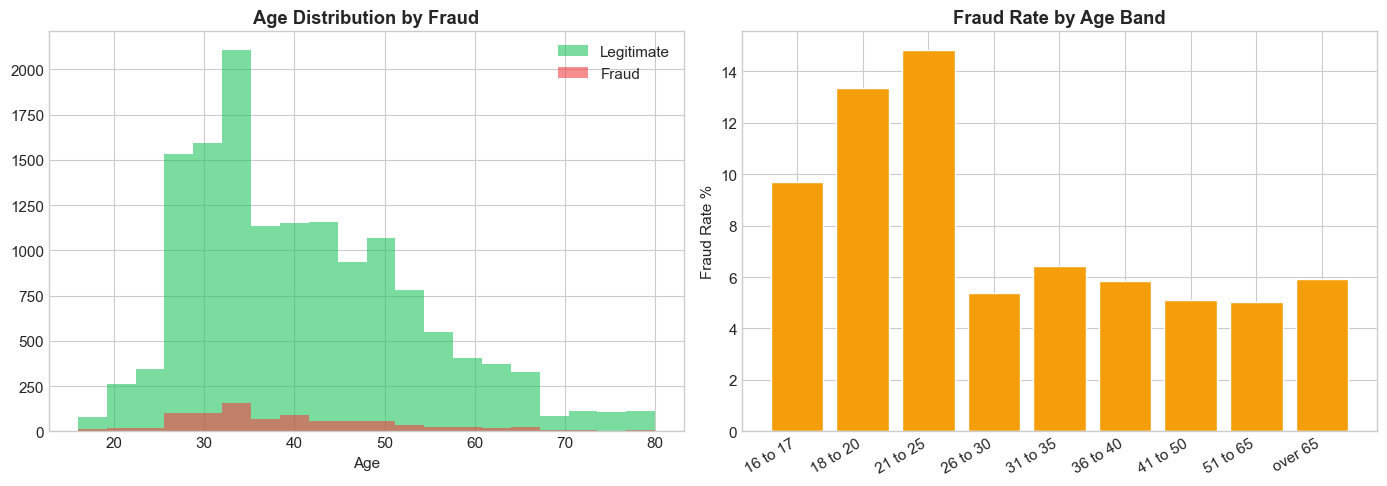

In [16]:
# Age vs Fraud
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_age = df[df['Age'] > 0].copy()
axes[0].hist(df_age[df_age['FraudFound_P']==0]['Age'], bins=20,
             alpha=0.6, color='#22C55E', label='Legitimate')
axes[0].hist(df_age[df_age['FraudFound_P']==1]['Age'], bins=20,
             alpha=0.6, color='#EF4444', label='Fraud')
axes[0].set_title('Age Distribution by Fraud', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].legend()

# Fraud rate by age band
fraud_by_age = df.groupby('AgeOfPolicyHolder')['FraudFound_P'].mean() * 100
age_order = ['16 to 17','18 to 20','21 to 25','26 to 30','31 to 35','36 to 40','41 to 50','51 to 65','over 65']
fraud_by_age = fraud_by_age.reindex([x for x in age_order if x in fraud_by_age.index])
axes[1].bar(range(len(fraud_by_age)), fraud_by_age.values,
            color='#F59E0B', edgecolor='white')
axes[1].set_xticks(range(len(fraud_by_age)))
axes[1].set_xticklabels(fraud_by_age.index, rotation=30, ha='right')
axes[1].set_title('Fraud Rate by Age Band', fontweight='bold')
axes[1].set_ylabel('Fraud Rate %')

plt.tight_layout()
plt.savefig('05_age_vs_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation Analysis

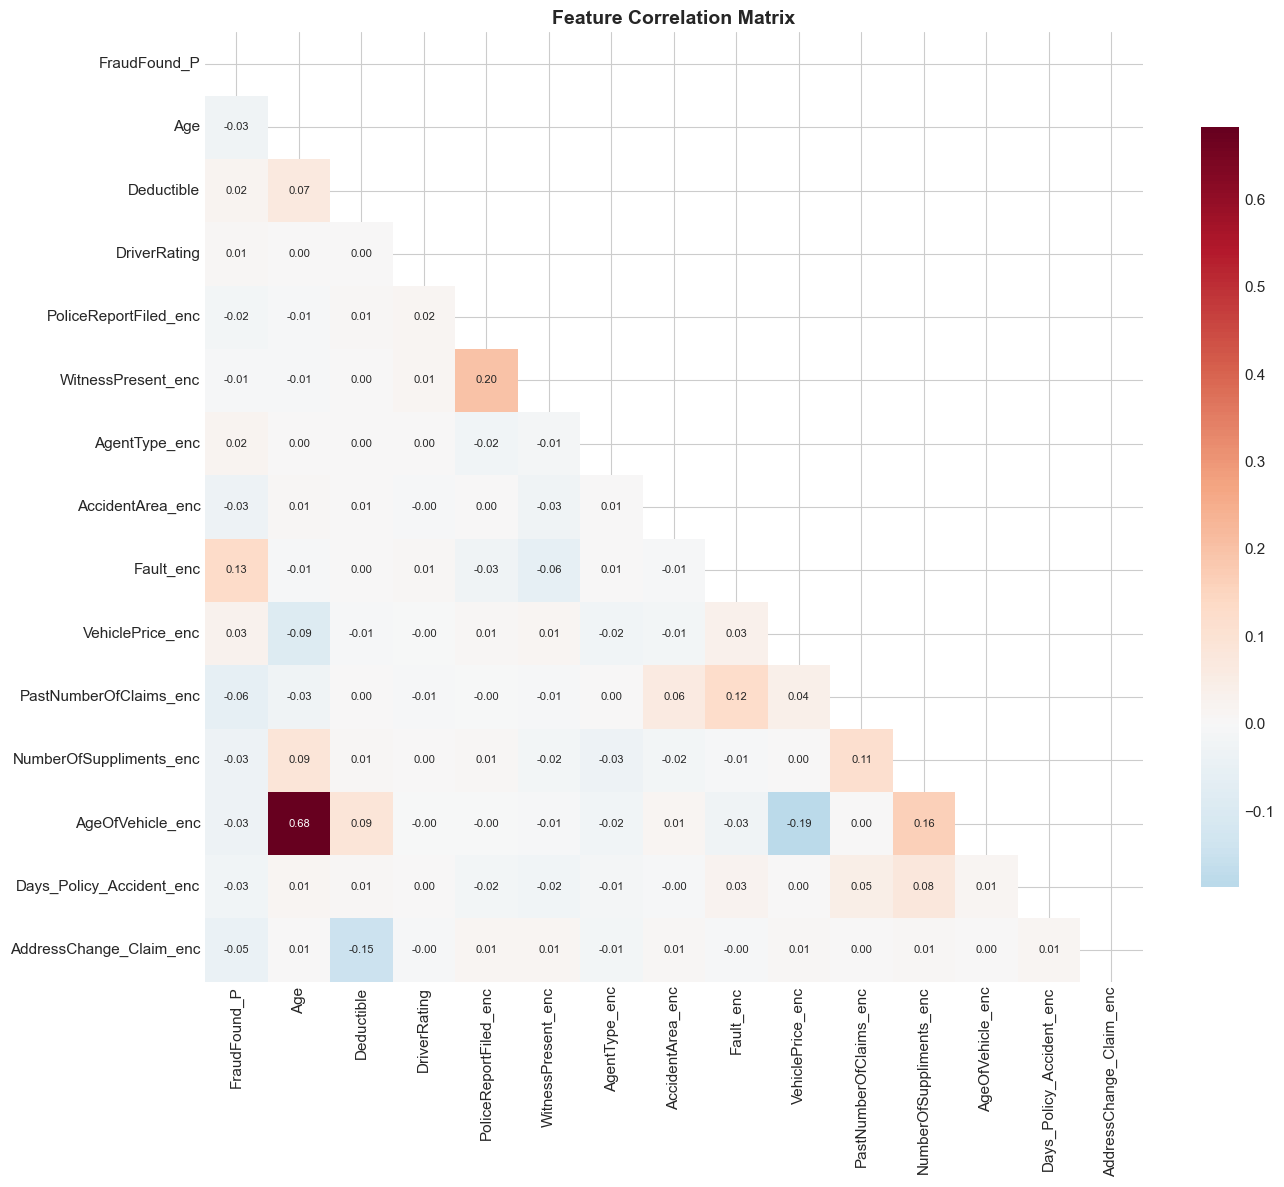

=== CORRELATIONS WITH FraudFound_P ===
Fault_enc                   0.131
PastNumberOfClaims_enc     -0.058
AddressChange_Claim_enc    -0.046
AccidentArea_enc           -0.033
AgeOfVehicle_enc           -0.033
NumberOfSuppliments_enc    -0.032
VehiclePrice_enc            0.032
Age                        -0.030
Days_Policy_Accident_enc   -0.026
AgentType_enc               0.023
Deductible                  0.017
PoliceReportFiled_enc      -0.016
WitnessPresent_enc         -0.008
DriverRating                0.007
Name: FraudFound_P, dtype: float64


In [17]:
# Encode categorical for correlation
df_enc = df.copy()
binary_map = {'Yes': 1, 'No': 0, 'External': 1, 'Internal': 0,
              'Urban': 1, 'Rural': 0, 'Policy Holder': 1, 'Third Party': 0}
for col in ['PoliceReportFiled','WitnessPresent','AgentType','AccidentArea','Fault']:
    df_enc[col+'_enc'] = df_enc[col].map(binary_map)

ordinal_maps = {
    'VehiclePrice': {'less than 20000':1,'20000 to 29000':2,'30000 to 39000':3,
                     '40000 to 59000':4,'60000 to 69000':5,'more than 69000':6},
    'PastNumberOfClaims': {'none':0,'1':1,'2 to 4':2,'more than 4':3},
    'NumberOfSuppliments': {'none':0,'1 to 2':1,'3 to 5':2,'more than 5':3},
    'AgeOfVehicle': {'new':0,'2 years':2,'3 years':3,'4 years':4,'5 years':5,
                     '6 years':6,'7 years':7,'more than 7':8},
    'Days_Policy_Accident': {'none':0,'1 to 7':1,'8 to 15':2,'15 to 30':3,'more than 30':4},
    'AddressChange_Claim': {'under 6 months':1,'1 year':2,'2 to 3 years':3,
                            '4 to 8 years':4,'no change':5},
}
for col, mapping in ordinal_maps.items():
    df_enc[col+'_enc'] = df_enc[col].map(mapping)

corr_cols = ['FraudFound_P','Age','Deductible','DriverRating',
             'PoliceReportFiled_enc','WitnessPresent_enc','AgentType_enc',
             'AccidentArea_enc','Fault_enc','VehiclePrice_enc',
             'PastNumberOfClaims_enc','NumberOfSuppliments_enc',
             'AgeOfVehicle_enc','Days_Policy_Accident_enc','AddressChange_Claim_enc']

corr_matrix = df_enc[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== CORRELATIONS WITH FraudFound_P ===')
fraud_corr = corr_matrix['FraudFound_P'].drop('FraudFound_P').sort_values(key=abs, ascending=False)
print(fraud_corr.round(3))

## 7. Deep Fraud Pattern Analysis

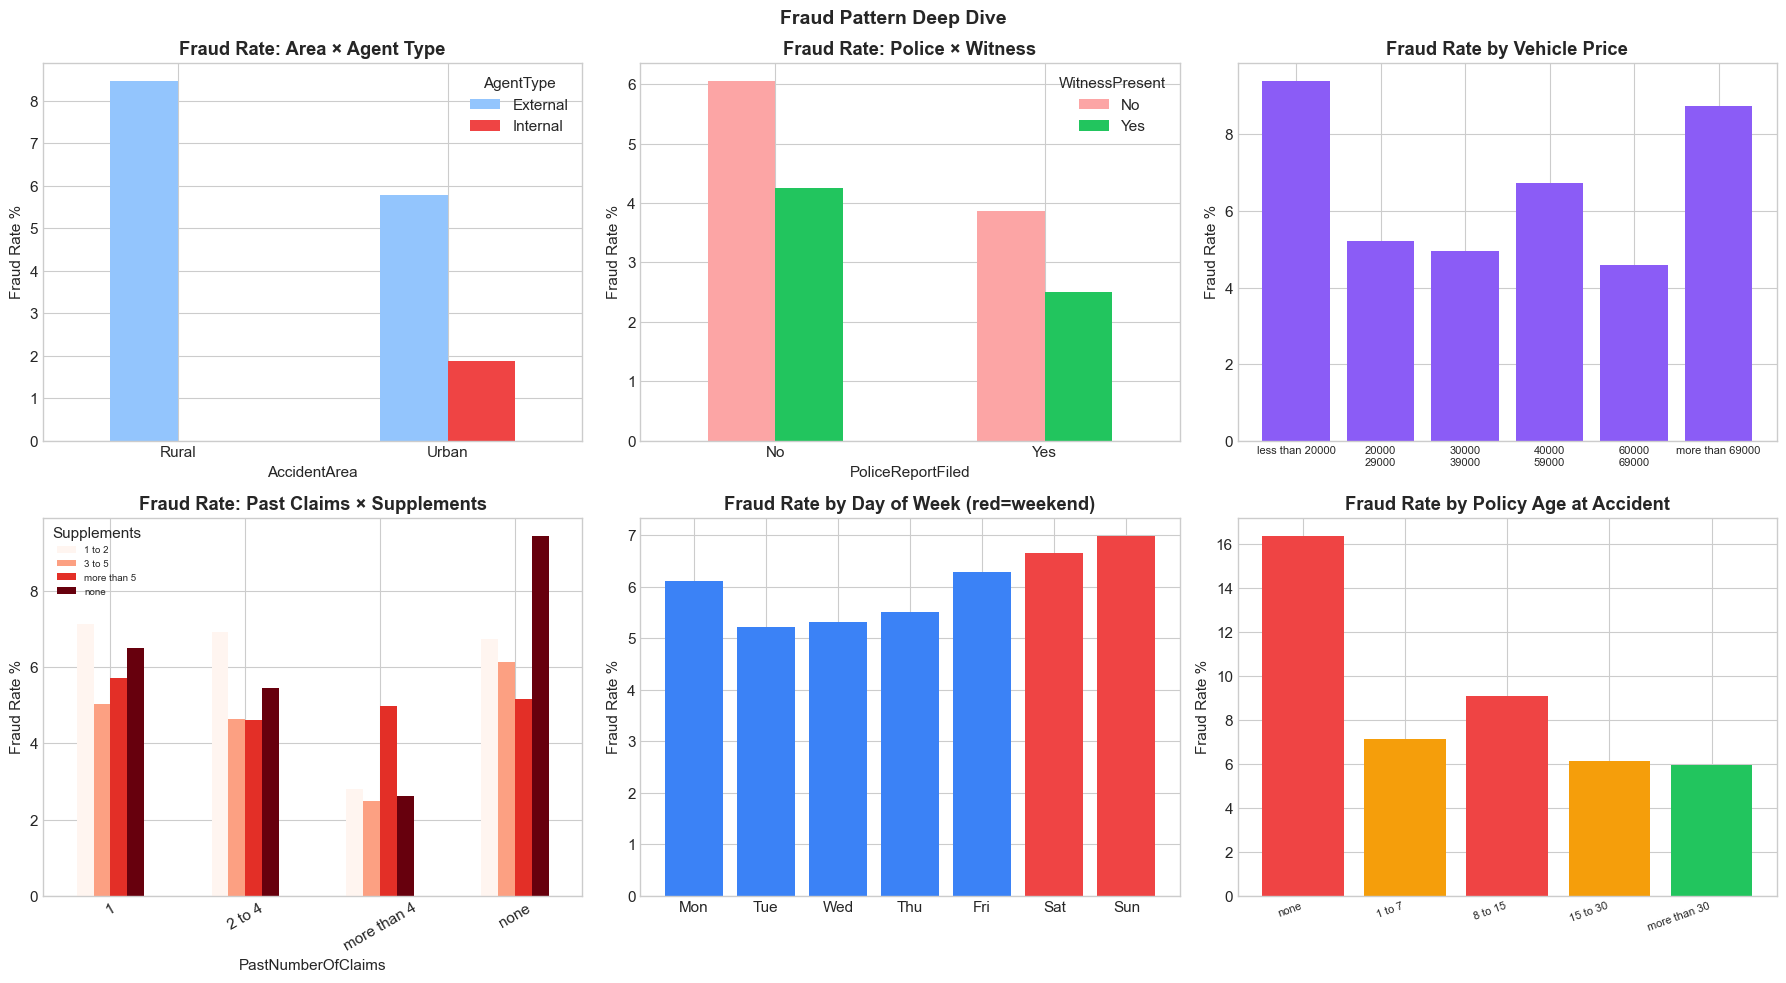

In [18]:
# Combined fraud patterns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Fraud by AccidentArea + AgentType
pivot1 = df.groupby(['AccidentArea','AgentType'])['FraudFound_P'].mean().unstack()*100
pivot1.plot(kind='bar', ax=axes[0][0], color=['#93C5FD','#EF4444'])
axes[0][0].set_title('Fraud Rate: Area × Agent Type', fontweight='bold')
axes[0][0].set_ylabel('Fraud Rate %')
axes[0][0].tick_params(axis='x', rotation=0)

# 2. Fraud by PoliceReport + WitnessPresent
pivot2 = df.groupby(['PoliceReportFiled','WitnessPresent'])['FraudFound_P'].mean().unstack()*100
pivot2.plot(kind='bar', ax=axes[0][1], color=['#FCA5A5','#22C55E'])
axes[0][1].set_title('Fraud Rate: Police × Witness', fontweight='bold')
axes[0][1].set_ylabel('Fraud Rate %')
axes[0][1].tick_params(axis='x', rotation=0)

# 3. Fraud by VehiclePrice
vp_order = ['less than 20000','20000 to 29000','30000 to 39000','40000 to 59000','60000 to 69000','more than 69000']
vp_fraud = df.groupby('VehiclePrice')['FraudFound_P'].mean().reindex(vp_order)*100
axes[0][2].bar(range(len(vp_fraud)), vp_fraud.values, color='#8B5CF6')
axes[0][2].set_xticks(range(len(vp_fraud)))
axes[0][2].set_xticklabels([x.replace(' to ','\n').replace('more than\n','>')
                              .replace('less than\n','<') for x in vp_order], fontsize=8)
axes[0][2].set_title('Fraud Rate by Vehicle Price', fontweight='bold')
axes[0][2].set_ylabel('Fraud Rate %')

# 4. Fraud by PastClaims + Supplements
pivot3 = df.groupby(['PastNumberOfClaims','NumberOfSuppliments'])['FraudFound_P'].mean().unstack()*100
pivot3.plot(kind='bar', ax=axes[1][0], colormap='Reds')
axes[1][0].set_title('Fraud Rate: Past Claims × Supplements', fontweight='bold')
axes[1][0].set_ylabel('Fraud Rate %')
axes[1][0].tick_params(axis='x', rotation=30)
axes[1][0].legend(fontsize=7, title='Supplements')

# 5. Fraud by DayOfWeek
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_fraud = df.groupby('DayOfWeek')['FraudFound_P'].mean().reindex(dow_order)*100
colors = ['#3B82F6']*5 + ['#EF4444']*2
axes[1][1].bar(range(7), dow_fraud.values, color=colors)
axes[1][1].set_xticks(range(7))
axes[1][1].set_xticklabels([d[:3] for d in dow_order])
axes[1][1].set_title('Fraud Rate by Day of Week (red=weekend)', fontweight='bold')
axes[1][1].set_ylabel('Fraud Rate %')

# 6. Fraud by Days_Policy_Accident
dpa_order = ['none','1 to 7','8 to 15','15 to 30','more than 30']
dpa_fraud = df.groupby('Days_Policy_Accident')['FraudFound_P'].mean().reindex(dpa_order)*100
bar_colors = ['#EF4444' if v > 8 else '#F59E0B' if v > 6 else '#22C55E'
              for v in dpa_fraud.values]
axes[1][2].bar(range(len(dpa_fraud)), dpa_fraud.values, color=bar_colors)
axes[1][2].set_xticks(range(len(dpa_fraud)))
axes[1][2].set_xticklabels(dpa_order, rotation=20, ha='right', fontsize=8)
axes[1][2].set_title('Fraud Rate by Policy Age at Accident', fontweight='bold')
axes[1][2].set_ylabel('Fraud Rate %')

plt.suptitle('Fraud Pattern Deep Dive', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_fraud_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Data Cleaning

In [19]:
df_clean = df.copy()
changes_log = []

# FIX 1: Rename misspelled column
df_clean = df_clean.rename(columns={'NumberOfSuppliments': 'NumberOfSupplements'})
changes_log.append('F1: Renamed NumberOfSuppliments → NumberOfSupplements')
print('F1: Column renamed')

F1: Column renamed


In [20]:
# FIX 2: Age = 0 → impute from AgeOfPolicyHolder band midpoint
band_midpoint = {
    '16 to 17': 16, '18 to 20': 19, '21 to 25': 23,
    '26 to 30': 28, '31 to 35': 33, '36 to 40': 38,
    '41 to 50': 45, '51 to 65': 58, 'over 65': 68
}
mask_zero = df_clean['Age'] == 0
df_clean.loc[mask_zero, 'Age'] = df_clean.loc[mask_zero, 'AgeOfPolicyHolder'].map(band_midpoint)
changes_log.append(f'F2: Imputed {mask_zero.sum()} Age=0 values from AgeOfPolicyHolder band midpoint')
print(f'F2: Fixed {mask_zero.sum()} Age=0 rows')
print('Remaining Age=0:', (df_clean['Age']==0).sum())

F2: Fixed 320 Age=0 rows
Remaining Age=0: 0


In [21]:
# FIX 3: DayOfWeekClaimed='0' and MonthClaimed='0' → impute from accident fields
mask_dow = df_clean['DayOfWeekClaimed'] == '0'
df_clean.loc[mask_dow, 'DayOfWeekClaimed'] = df_clean.loc[mask_dow, 'DayOfWeek']
df_clean.loc[df_clean['MonthClaimed'] == '0', 'MonthClaimed'] = df_clean.loc[df_clean['MonthClaimed'] == '0', 'Month']
changes_log.append('F3: Imputed DayOfWeekClaimed=0 from DayOfWeek, MonthClaimed=0 from Month')
print(f'F3: Fixed {mask_dow.sum()} DayOfWeekClaimed=0 rows')

F3: Fixed 1 DayOfWeekClaimed=0 rows


In [22]:
# FIX 4: PolicyType — derive correctly from VehicleCategory + BasePolicy
df_clean['PolicyType'] = df_clean['VehicleCategory'] + ' - ' + df_clean['BasePolicy']
# Verify
remaining_mismatch = (df_clean['PolicyType'] != df_clean['VehicleCategory'] + ' - ' + df_clean['BasePolicy']).sum()
changes_log.append(f'F4: Corrected PolicyType = VehicleCategory + BasePolicy ({4987} mismatches fixed)')
print(f'F4: PolicyType corrected. Remaining mismatches: {remaining_mismatch}')
print(df_clean['PolicyType'].value_counts())

F4: PolicyType corrected. Remaining mismatches: 0
PolicyType
Sedan - Collision       5584
Sport - Liability       4988
Sedan - All Perils      4087
Sport - Collision        348
Utility - All Perils     340
Utility - Collision       30
Sport - All Perils        22
Utility - Liability       21
Name: count, dtype: int64


In [23]:
# FIX 5: Age vs AgeOfPolicyHolder — re-impute Age from band midpoint for all mismatches
# Trust AgeOfPolicyHolder over Age (band is more reliable in this dataset)
def needs_fix(row):
    band = age_map.get(row['AgeOfPolicyHolder'])
    if not band: return False
    return not (band[0] <= row['Age'] <= band[1])

mask_age_mismatch = df_clean.apply(needs_fix, axis=1)
df_clean.loc[mask_age_mismatch, 'Age'] = df_clean.loc[mask_age_mismatch, 'AgeOfPolicyHolder'].map(band_midpoint)
changes_log.append(f'F5: Corrected {mask_age_mismatch.sum()} Age values that fell outside AgeOfPolicyHolder band')
print(f'F5: Corrected {mask_age_mismatch.sum()} Age mismatches')

# Verify
remaining_mismatch = df_clean.apply(needs_fix, axis=1).sum()
print(f'Remaining Age mismatches: {remaining_mismatch}')

F5: Corrected 6922 Age mismatches
Remaining Age mismatches: 0


In [24]:
# FIX 6: Days_Policy_Accident = 'none' → recode as '1 to 7' (new policy, high risk)
mask_dpa_none = df_clean['Days_Policy_Accident'] == 'none'
df_clean.loc[mask_dpa_none, 'Days_Policy_Accident'] = '1 to 7'
changes_log.append(f'F6: Recoded {mask_dpa_none.sum()} Days_Policy_Accident=none to 1 to 7')
print(f'F6: Recoded {mask_dpa_none.sum()} none values in Days_Policy_Accident')

# Days_Policy_Claim = 'none' → 'more than 30' (most conservative)
mask_dpc_none = df_clean['Days_Policy_Claim'] == 'none'
df_clean.loc[mask_dpc_none, 'Days_Policy_Claim'] = 'more than 30'
changes_log.append(f'F6b: Recoded {mask_dpc_none.sum()} Days_Policy_Claim=none to more than 30')
print(f'F6b: Recoded {mask_dpc_none.sum()} none values in Days_Policy_Claim')

F6: Recoded 55 none values in Days_Policy_Accident
F6b: Recoded 1 none values in Days_Policy_Claim


In [25]:
# Drop PolicyType_prefix helper column if it exists
if 'PolicyType_prefix' in df_clean.columns:
    df_clean = df_clean.drop(columns=['PolicyType_prefix'])
if 'month_num' in df_clean.columns:
    df_clean = df_clean.drop(columns=['month_num','month_claimed_num'])

# Verify clean dataset
print('=== CLEAN DATASET VERIFICATION ===')
print(f'Shape: {df_clean.shape}')
print(f'Missing values: {df_clean.isnull().sum().sum()}')
print(f'Age=0 remaining: {(df_clean["Age"]==0).sum()}')
print(f'DayOfWeekClaimed=0 remaining: {(df_clean["DayOfWeekClaimed"]=="0").sum()}')
print(f'MonthClaimed=0 remaining: {(df_clean["MonthClaimed"]=="0").sum()}')
print(f'Fraud rate: {df_clean["FraudFound_P"].mean()*100:.2f}% (unchanged)')
print(f'\nChanges applied:')
for c in changes_log:
    print(f'  ✓ {c}')

=== CLEAN DATASET VERIFICATION ===
Shape: (15420, 33)
Missing values: 0
Age=0 remaining: 0
DayOfWeekClaimed=0 remaining: 0
MonthClaimed=0 remaining: 0
Fraud rate: 5.99% (unchanged)

Changes applied:
  ✓ F1: Renamed NumberOfSuppliments → NumberOfSupplements
  ✓ F2: Imputed 320 Age=0 values from AgeOfPolicyHolder band midpoint
  ✓ F3: Imputed DayOfWeekClaimed=0 from DayOfWeek, MonthClaimed=0 from Month
  ✓ F4: Corrected PolicyType = VehicleCategory + BasePolicy (4987 mismatches fixed)
  ✓ F5: Corrected 6922 Age values that fell outside AgeOfPolicyHolder band
  ✓ F6: Recoded 55 Days_Policy_Accident=none to 1 to 7
  ✓ F6b: Recoded 1 Days_Policy_Claim=none to more than 30


## 9. Feature Engineering

In [26]:
df_fe = df_clean.copy()

# FE1: IsWeekend — weekend accidents have higher fraud rate
df_fe['IsWeekend'] = df_fe['DayOfWeek'].isin(['Saturday','Sunday']).astype(int)
print(f'FE1: IsWeekend — fraud rate: weekday {df_fe[df_fe["IsWeekend"]==0]["FraudFound_P"].mean():.3f} vs weekend {df_fe[df_fe["IsWeekend"]==1]["FraudFound_P"].mean():.3f}')

# FE2: NoEvidence — no police AND no witness (combined risk signal)
df_fe['NoEvidence'] = ((df_fe['PoliceReportFiled']=='No') & (df_fe['WitnessPresent']=='No')).astype(int)
print(f'FE2: NoEvidence — fraud rate: evidence {df_fe[df_fe["NoEvidence"]==0]["FraudFound_P"].mean():.3f} vs no evidence {df_fe[df_fe["NoEvidence"]==1]["FraudFound_P"].mean():.3f}')

# FE3: IsHighValueClaim — vehicle price in top 2 bands
df_fe['IsHighValueClaim'] = df_fe['VehiclePrice'].isin(['60000 to 69000','more than 69000']).astype(int)
print(f'FE3: IsHighValueClaim — fraud rate: low {df_fe[df_fe["IsHighValueClaim"]==0]["FraudFound_P"].mean():.3f} vs high {df_fe[df_fe["IsHighValueClaim"]==1]["FraudFound_P"].mean():.3f}')

# FE4: IsNewPolicy — Days_Policy_Accident = 1 to 7
df_fe['IsNewPolicy'] = df_fe['Days_Policy_Accident'].isin(['1 to 7']).astype(int)
print(f'FE4: IsNewPolicy — fraud rate: old {df_fe[df_fe["IsNewPolicy"]==0]["FraudFound_P"].mean():.3f} vs new {df_fe[df_fe["IsNewPolicy"]==1]["FraudFound_P"].mean():.3f}')

# FE5: IsRepeatClaimant — PastNumberOfClaims > 1
df_fe['IsRepeatClaimant'] = df_fe['PastNumberOfClaims'].isin(['2 to 4','more than 4']).astype(int)
print(f'FE5: IsRepeatClaimant — fraud rate: first {df_fe[df_fe["IsRepeatClaimant"]==0]["FraudFound_P"].mean():.3f} vs repeat {df_fe[df_fe["IsRepeatClaimant"]==1]["FraudFound_P"].mean():.3f}')

# FE6: HasExcessSupplements — NumberOfSupplements > 2
df_fe['HasExcessSupplements'] = df_fe['NumberOfSupplements'].isin(['3 to 5','more than 5']).astype(int)
print(f'FE6: HasExcessSupplements — fraud rate: normal {df_fe[df_fe["HasExcessSupplements"]==0]["FraudFound_P"].mean():.3f} vs excess {df_fe[df_fe["HasExcessSupplements"]==1]["FraudFound_P"].mean():.3f}')

# FE7: IsOldHighValueVehicle — AgeOfVehicle > 7 AND high price
df_fe['IsOldHighValueVehicle'] = ((df_fe['AgeOfVehicle']=='more than 7') & (df_fe['IsHighValueClaim']==1)).astype(int)
print(f'FE7: IsOldHighValueVehicle — fraud rate: {df_fe[df_fe["IsOldHighValueVehicle"]==1]["FraudFound_P"].mean():.3f}')

# FE8: RecentAddressChange — under 6 months
df_fe['RecentAddressChange'] = (df_fe['AddressChange_Claim']=='under 6 months').astype(int)
print(f'FE8: RecentAddressChange — fraud rate: no change {df_fe[df_fe["RecentAddressChange"]==0]["FraudFound_P"].mean():.3f} vs recent {df_fe[df_fe["RecentAddressChange"]==1]["FraudFound_P"].mean():.3f}')

# FE9: IsExternalAgent
df_fe['IsExternalAgent'] = (df_fe['AgentType']=='External').astype(int)
print(f'FE9: IsExternalAgent — fraud rate: internal {df_fe[df_fe["IsExternalAgent"]==0]["FraudFound_P"].mean():.3f} vs external {df_fe[df_fe["IsExternalAgent"]==1]["FraudFound_P"].mean():.3f}')

# FE10: FraudRiskScore_Simple — sum of binary risk flags (0-9 scale)
risk_flags = ['NoEvidence','IsHighValueClaim','IsRepeatClaimant','HasExcessSupplements',
              'IsOldHighValueVehicle','RecentAddressChange','IsExternalAgent',
              'IsWeekend','IsNewPolicy']
df_fe['FraudRiskFlags'] = df_fe[risk_flags].sum(axis=1)
print(f'\nFE10: FraudRiskFlags distribution:')
flag_fraud = df_fe.groupby('FraudRiskFlags')['FraudFound_P'].agg(['mean','count'])
flag_fraud.columns = ['fraud_rate','count']
flag_fraud['fraud_rate'] = (flag_fraud['fraud_rate']*100).round(2)
print(flag_fraud)

FE1: IsWeekend — fraud rate: weekday 0.057 vs weekend 0.068
FE2: NoEvidence — fraud rate: evidence 0.038 vs no evidence 0.061
FE3: IsHighValueClaim — fraud rate: low 0.055 vs high 0.086
FE4: IsNewPolicy — fraud rate: old 0.059 vs new 0.145
FE5: IsRepeatClaimant — fraud rate: first 0.071 vs repeat 0.048
FE6: HasExcessSupplements — fraud rate: normal 0.066 vs excess 0.050
FE7: IsOldHighValueVehicle — fraud rate: 0.071
FE8: RecentAddressChange — fraud rate: no change 0.060 vs recent 0.750
FE9: IsExternalAgent — fraud rate: internal 0.017 vs external 0.061

FE10: FraudRiskFlags distribution:
                fraud_rate  count
FraudRiskFlags                   
0                     0.00      3
1                     2.94    136
2                     6.05   3374
3                     6.26   6099
4                     5.79   4321
5                     6.06   1237
6                     3.12    224
7                     3.85     26


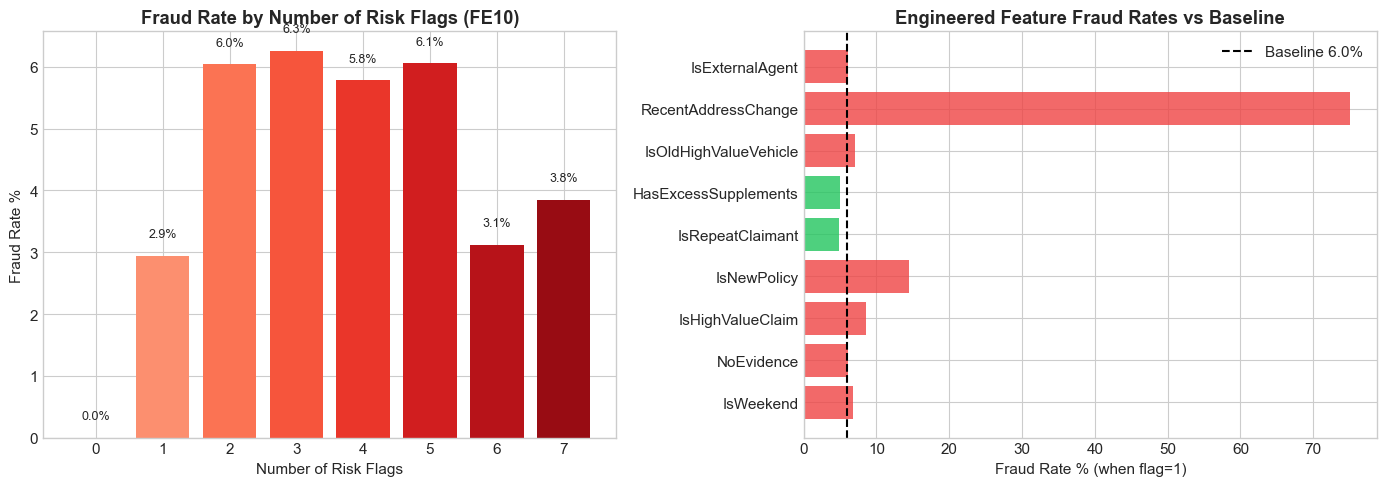

In [27]:
# Visualize FraudRiskFlags vs fraud rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

flag_fraud_plot = df_fe.groupby('FraudRiskFlags')['FraudFound_P'].mean() * 100
axes[0].bar(flag_fraud_plot.index, flag_fraud_plot.values,
            color=plt.cm.Reds(np.linspace(0.3, 0.9, len(flag_fraud_plot))))
axes[0].set_xlabel('Number of Risk Flags')
axes[0].set_ylabel('Fraud Rate %')
axes[0].set_title('Fraud Rate by Number of Risk Flags (FE10)', fontweight='bold')
for i, v in zip(flag_fraud_plot.index, flag_fraud_plot.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# New features fraud rate comparison
fe_features = ['IsWeekend','NoEvidence','IsHighValueClaim','IsNewPolicy',
               'IsRepeatClaimant','HasExcessSupplements','IsOldHighValueVehicle',
               'RecentAddressChange','IsExternalAgent']
fe_fraud_rates = [df_fe[df_fe[f]==1]['FraudFound_P'].mean()*100 for f in fe_features]
baseline = df_fe['FraudFound_P'].mean()*100

colors = ['#EF4444' if r > baseline else '#22C55E' for r in fe_fraud_rates]
axes[1].barh(fe_features, fe_fraud_rates, color=colors, alpha=0.8)
axes[1].axvline(baseline, color='black', linestyle='--', linewidth=1.5, label=f'Baseline {baseline:.1f}%')
axes[1].set_xlabel('Fraud Rate % (when flag=1)')
axes[1].set_title('Engineered Feature Fraud Rates vs Baseline', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('08_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Final Summary & Export

In [28]:
print('=== FINAL DATASET SUMMARY ===')
print(f'Original rows:  {len(df):,}')
print(f'Cleaned rows:   {len(df_fe):,}  (no rows removed)')
print(f'Original cols:  {df.shape[1]}')
print(f'Final cols:     {df_fe.shape[1]}  (+{df_fe.shape[1]-df.shape[1]} engineered)')
print(f'Fraud rate:     {df_fe["FraudFound_P"].mean()*100:.2f}%  (unchanged)')
print()
print('=== CHANGES APPLIED ===')
for c in changes_log:
    print(f'  ✓ {c}')
print()
print('=== NEW FEATURES ADDED ===')
new_cols = [c for c in df_fe.columns if c not in df.columns and c != 'PolicyType_prefix']
for c in new_cols:
    print(f'  + {c}')
print()
print('=== COLUMNS IN FINAL DATASET ===')
print(df_fe.columns.tolist())

=== FINAL DATASET SUMMARY ===
Original rows:  15,420
Cleaned rows:   15,420  (no rows removed)
Original cols:  34
Final cols:     43  (+9 engineered)
Fraud rate:     5.99%  (unchanged)

=== CHANGES APPLIED ===
  ✓ F1: Renamed NumberOfSuppliments → NumberOfSupplements
  ✓ F2: Imputed 320 Age=0 values from AgeOfPolicyHolder band midpoint
  ✓ F3: Imputed DayOfWeekClaimed=0 from DayOfWeek, MonthClaimed=0 from Month
  ✓ F4: Corrected PolicyType = VehicleCategory + BasePolicy (4987 mismatches fixed)
  ✓ F5: Corrected 6922 Age values that fell outside AgeOfPolicyHolder band
  ✓ F6: Recoded 55 Days_Policy_Accident=none to 1 to 7
  ✓ F6b: Recoded 1 Days_Policy_Claim=none to more than 30

=== NEW FEATURES ADDED ===
  + NumberOfSupplements
  + IsWeekend
  + NoEvidence
  + IsHighValueClaim
  + IsNewPolicy
  + IsRepeatClaimant
  + HasExcessSupplements
  + IsOldHighValueVehicle
  + RecentAddressChange
  + IsExternalAgent
  + FraudRiskFlags

=== COLUMNS IN FINAL DATASET ===
['Month', 'WeekOfMonth', '

In [ ]:
# Export cleaned dataset
output_path = 'D:\FDE\InsurIQ\Data\fraud_oracle_cleaned.csv'
df_fe.to_csv(output_path, index=False)
print(f'Saved cleaned dataset to: {output_path}')
print(f'Shape: {df_fe.shape}')

# Also save original cleaned (without FE) for comparison
output_path_clean = 'D:\FDE\InsurIQ\Data\fraud_oracle_fixed.csv'
df_clean.to_csv(output_path_clean, index=False)
print(f'Saved fixes-only dataset to: {output_path_clean}')

# Preview
df_fe.head(3)

In [ ]:
# Final comparison: original vs cleaned
print('=== BEFORE vs AFTER ===')
compare = pd.DataFrame({
    'Metric': [
        'Rows', 'Columns', 'Age=0 count', 'DayOfWeekClaimed=0',
        'PolicyType mismatches', 'Age-Band mismatches',
        'Days_Policy_Accident=none', 'Fraud rate',
        'Column name typo'
    ],
    'Before': [
        15420, 33, 320, 1, 4987, 7242, 55,
        f"{df['FraudFound_P'].mean()*100:.2f}%",
        'NumberOfSuppliments'
    ],
    'After': [
        15420, df_fe.shape[1], 0, 0, 0, 0, 0,
        f"{df_fe['FraudFound_P'].mean()*100:.2f}%",
        'NumberOfSupplements'
    ],
    'Status': ['✅','✅','✅','✅','✅','✅','✅','✅','✅']
})
print(compare.to_string(index=False))